# 01 - Exploratory Data Analysis
Student Lifestyle and Stress Prediction Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/student-lifestyle-and-stress-dataset.csv")
df.head(20)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
5,college,4.914849,NaN,2.141137,85.144095,3.0,5.0,5.0,0
6,college,6.621709,5.261762,4.879102,NaN,4.0,7.0,7.0,0
7,college,6.357065,2.827955,6.198479,74.180341,7.0,8.0,6.0,0
8,college,8.085219,5.043731,4.660604,89.564367,3.0,2.0,7.0,0
9,college,4.627502,4.743084,5.579822,95.794315,5.0,5.0,10.0,0


In [2]:
df.tail(20)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
25480,college,4.936169,NaN,0.799807,95.779415,7.0,6.0,NaN,0
25481,college,8.333111,0.493976,3.571989,97.459651,5.0,7.0,2.0,0
25482,working_student,7.271539,5.702977,5.070094,83.307445,5.0,5.0,10.0,0
25483,working_student,NaN,6.538196,3.907358,87.507267,9.0,3.0,5.0,0
25484,school,7.641272,1.459643,2.776239,73.974163,10.0,8.0,1.0,1
25485,college,7.729355,4.984410,1.709946,89.300770,7.0,6.0,12.0,0
25486,college,4.646271,6.796307,4.976629,87.160842,9.0,4.0,7.0,1
25487,school,8.176374,0.998903,3.390113,76.072468,8.0,1.0,9.0,0
25488,school,7.890344,2.720544,3.548724,98.062224,9.0,7.0,9.0,0
25489,school,7.577951,3.912475,4.631579,89.805742,6.0,9.0,1.0,0


In [3]:
df.shape

(25500, 9)

In [4]:
df['Exam_Pressure'].unique()

array([ 8.,  6.,  7.,  2.,  5.,  3.,  4., nan,  9.,  1., 10.])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  str    
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 1.8 MB


In [6]:
df.isnull().sum()

Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df.columns

Index(['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
       'Attendance', 'Exam_Pressure', 'Family_Support', 'Month',
       'Stress_Level'],
      dtype='str')

In [9]:
df['Student_Type'].isnull().sum()

np.int64(1252)

In [10]:
df.describe(exclude=np.number)

,Student_Type
count,24248
unique,3
top,college
freq,13391


## Distribution plots for each feature

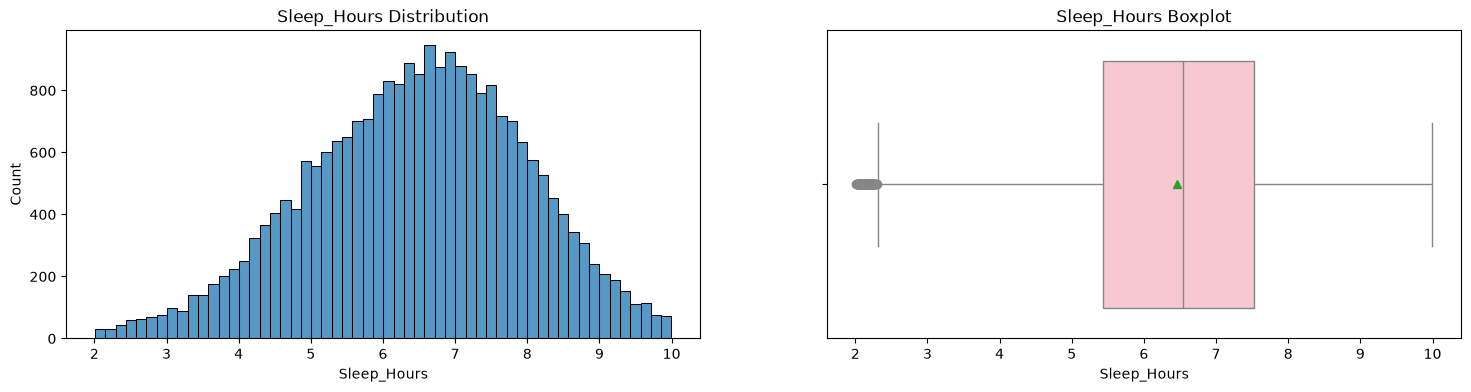

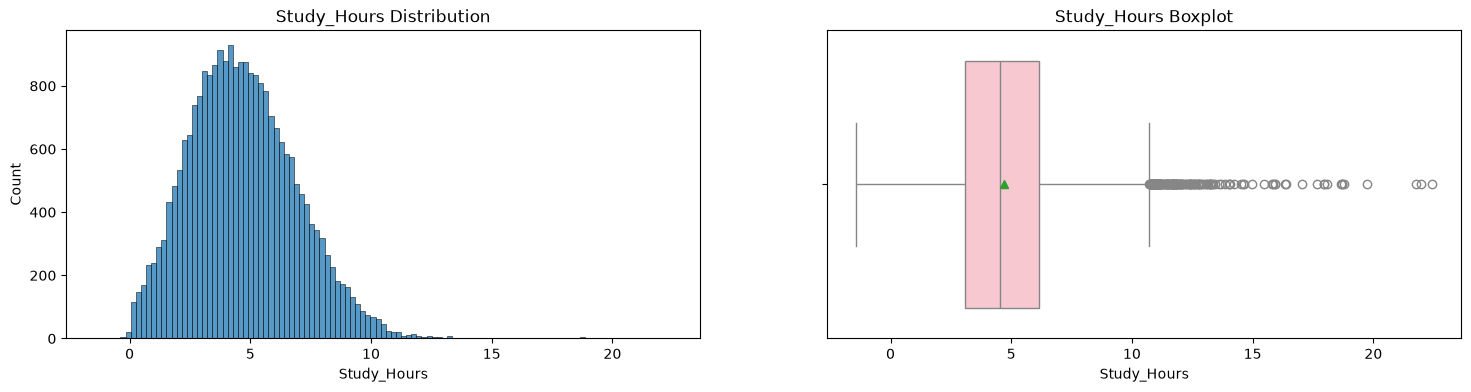

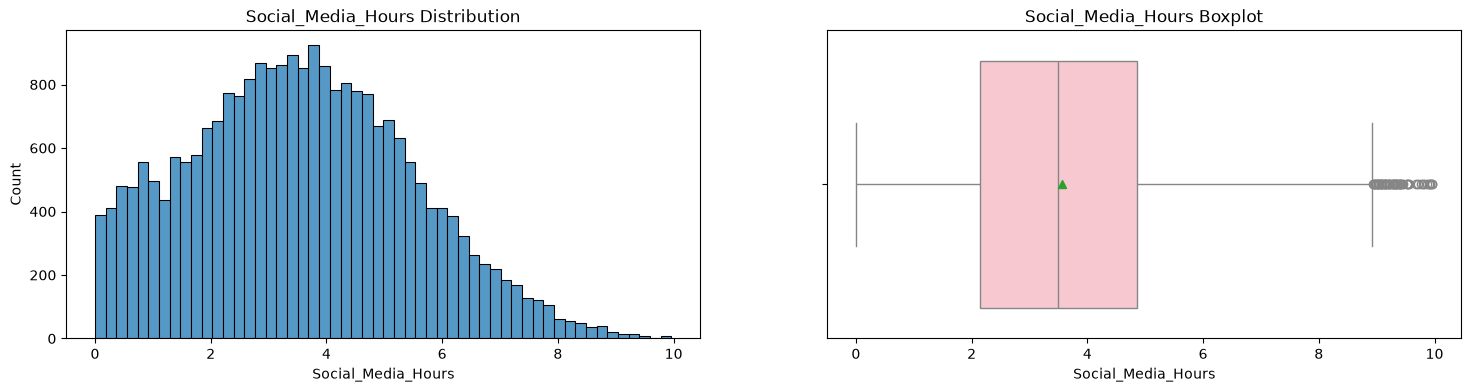

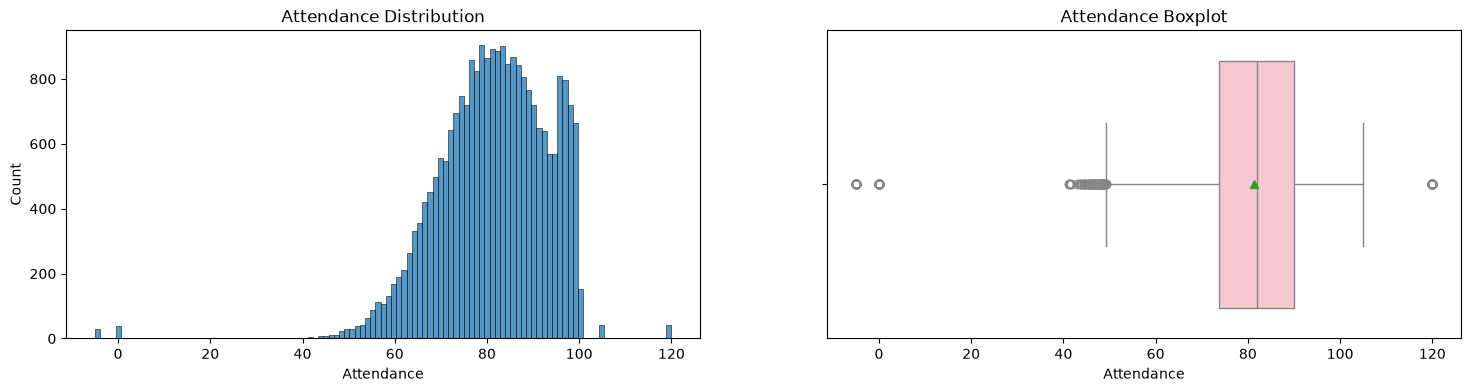

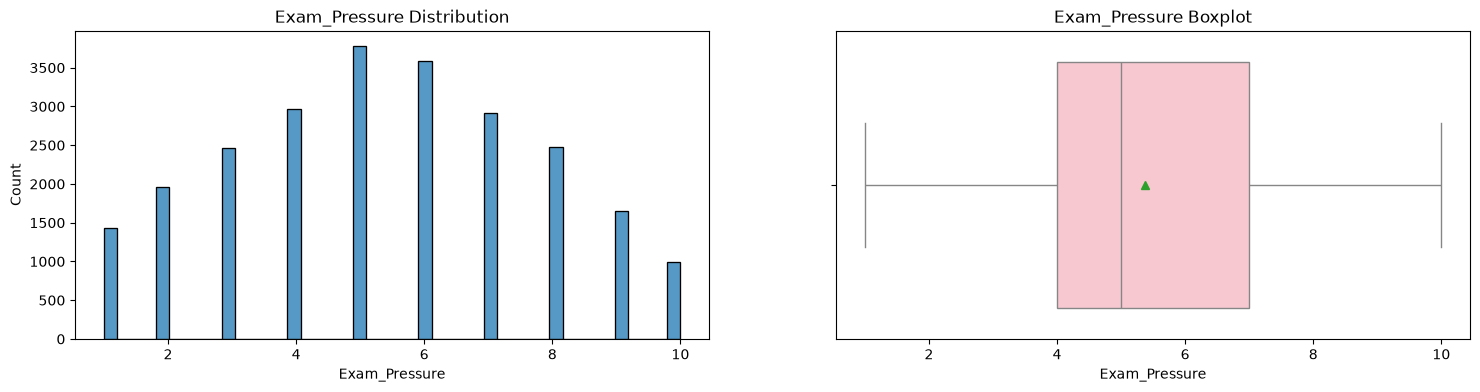

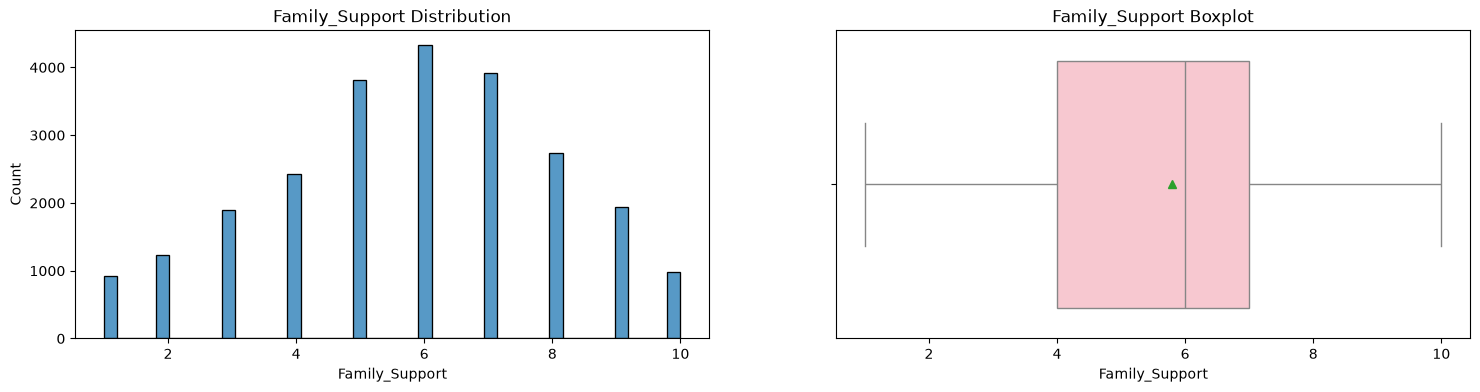

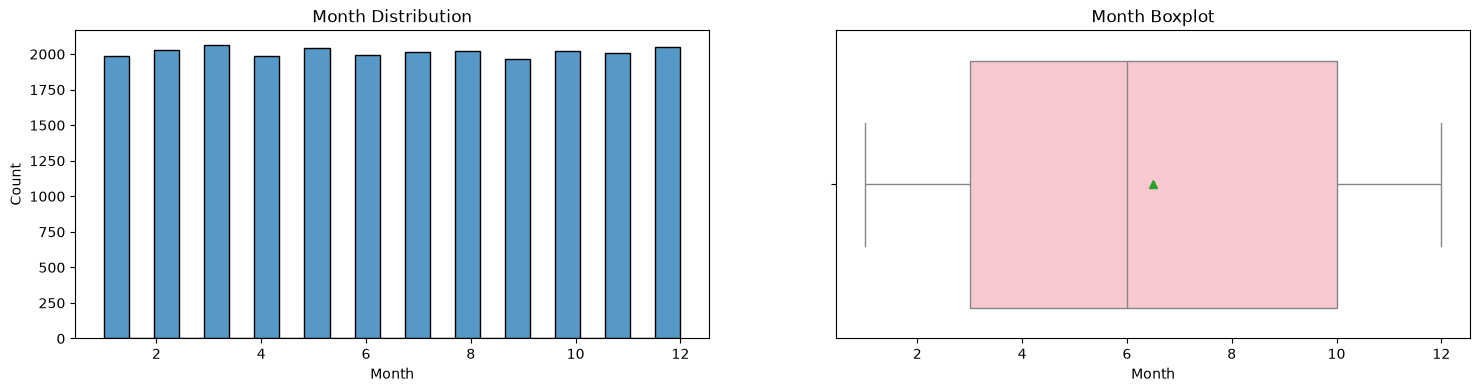

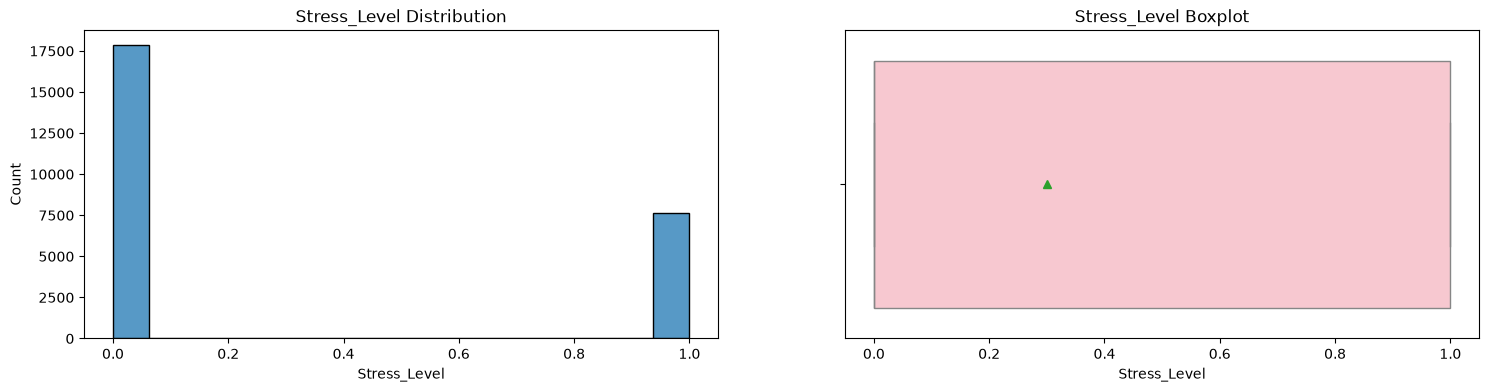

In [11]:
x_axis = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
          'Attendance', 'Exam_Pressure', 'Family_Support', 'Month',
          'Stress_Level']
for x in x_axis:
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    sns.histplot(df[x], ax=axes[0])
    axes[0].set_title(f"{x} Distribution")
    sns.boxplot(x=df[x], ax=axes[1], orient="h", showmeans=True, color="pink")
    axes[1].set_title(f"{x} Boxplot")
    plt.show()

## Duplicate check

In [12]:
duplicates = df[df.duplicated()]
duplicates.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
1126,college,5.568207,NaN,5.909244,97.456885,6.0,9.0,9.0,1
4072,college,8.148713,NaN,6.784068,85.370769,1.0,9.0,5.0,0
4790,college,4.277435,NaN,3.655623,79.375474,7.0,1.0,9.0,1
10050,school,8.478522,NaN,6.113217,65.564709,6.0,5.0,1.0,0
10182,school,8.036559,NaN,2.692154,65.579372,1.0,9.0,6.0,0


## Missing value analysis

In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage (%)": missing_percentage.round(2)
})
missing_table

,Missing Values,Missing Percentage (%)
Student_Type,1252,4.91
Sleep_Hours,1333,5.23
Study_Hours,1277,5.01
Social_Media_Hours,1312,5.15
Attendance,1305,5.12
Exam_Pressure,1270,4.98
Family_Support,1291,5.06
Month,1314,5.15
Stress_Level,0,0.00


In [14]:
rows_with_missing = df[df.isnull().any(axis=1)]
print("Rows containing at least one missing value:", rows_with_missing.shape[0])

missing_rows = df[df.isnull().any(axis=1)].shape[0]
print(f"Rows with missing values: {missing_rows}")
print(f"Percentage: {(missing_rows/len(df))*100:.2f}%")

missing_pct = df.isnull().mean() * 100
print(missing_pct)

Rows containing at least one missing value: 8691
Rows with missing values: 8691
Percentage: 34.08%
Student_Type          4.909804
Sleep_Hours           5.227451
Study_Hours           5.007843
Social_Media_Hours    5.145098
Attendance            5.117647
Exam_Pressure         4.980392
Family_Support        5.062745
Month                 5.152941
Stress_Level          0.000000
dtype: float64


## Numerical column distributions and skew

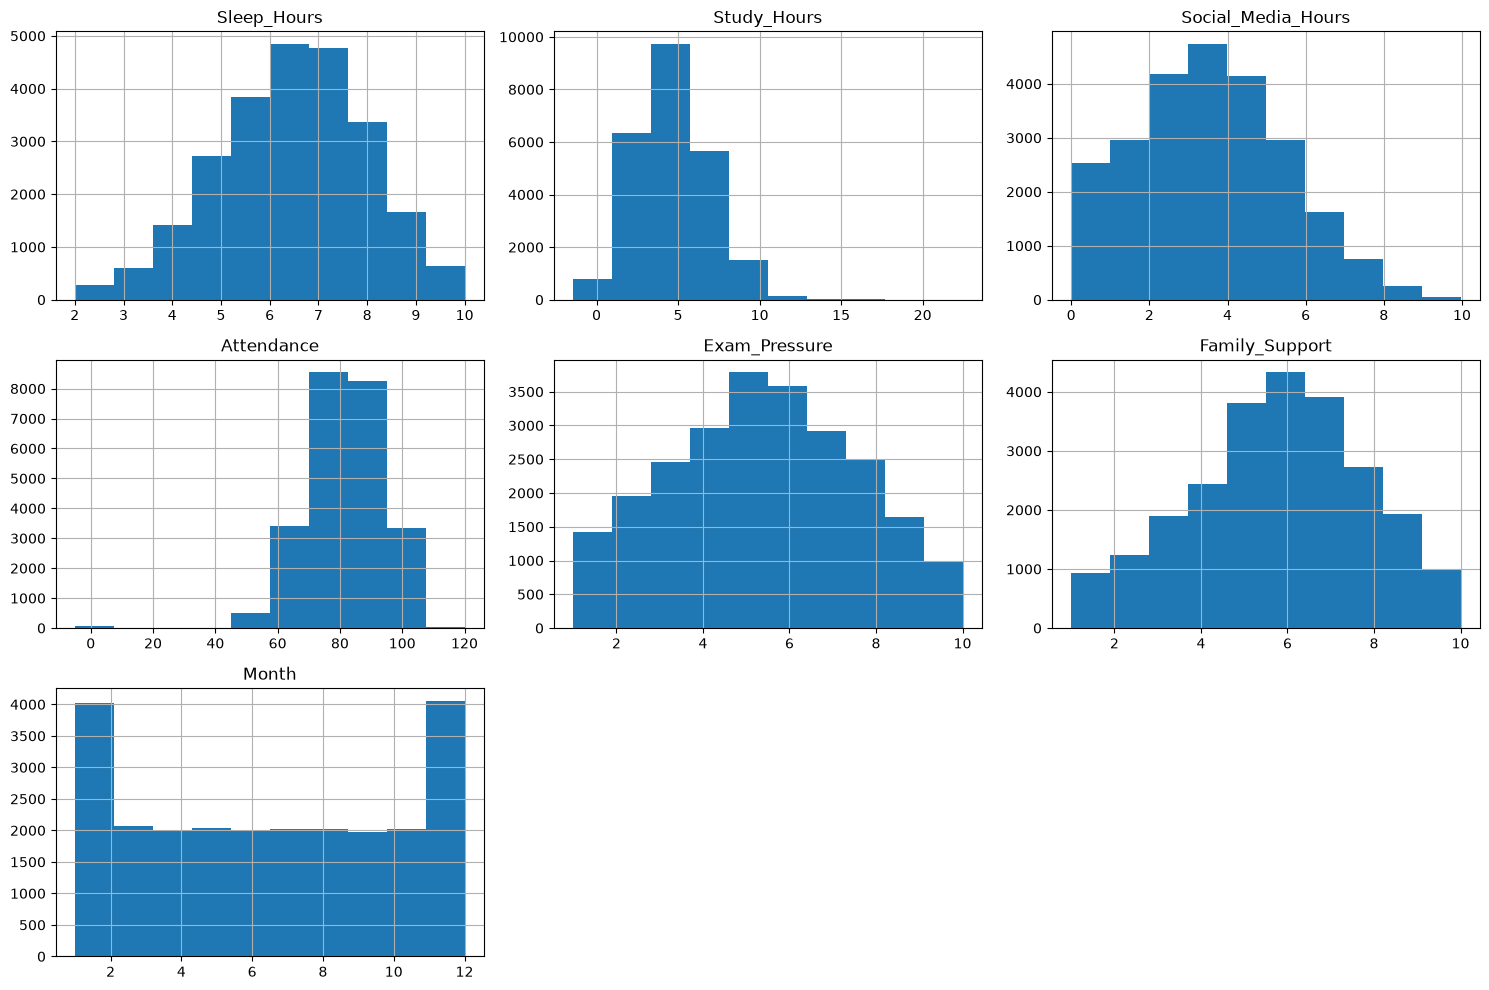

In [15]:
numerical_cols = [
    'Sleep_Hours',
    'Study_Hours',
    'Social_Media_Hours',
    'Attendance',
    'Exam_Pressure',
    'Family_Support',
    'Month'
]
df[numerical_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [16]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Sleep_Hours,24167.0,6.458948,1.504228,2.008586,5.438360,6.542566,7.531571,9.997527
Study_Hours,24223.0,4.696477,2.240148,-1.433434,3.078230,4.538138,6.135670,22.444460
Social_Media_Hours,24188.0,3.555614,1.901528,0.000040,2.152249,3.500709,4.864312,9.962134
Attendance,24195.0,81.270961,12.052045,-5.000000,73.738894,81.942959,90.106859,120.000000
Exam_Pressure,24230.0,5.369748,2.394003,1.000000,4.000000,5.000000,7.000000,10.000000
Family_Support,24209.0,5.798298,2.232371,1.000000,4.000000,6.000000,7.000000,10.000000
Month,24186.0,6.500992,3.455308,1.000000,3.000000,6.000000,10.000000,12.000000


In [17]:
df[numerical_cols].skew()

Sleep_Hours          -0.232006
Study_Hours           0.554843
Social_Media_Hours    0.253567
Attendance           -1.126708
Exam_Pressure         0.005089
Family_Support       -0.208103
Month                 0.005288
dtype: float64

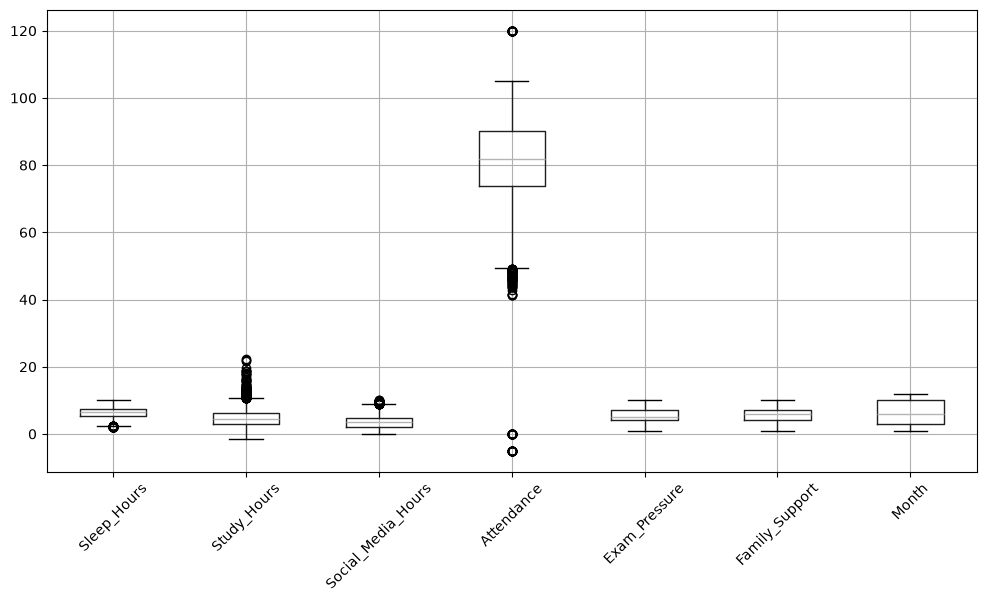

In [18]:
plt.figure(figsize=(12, 6))
df[numerical_cols].boxplot(rot=45)
plt.show()

## Checking for invalid values
These checks informed the cleaning rules now in `src/data_loader.py`

In [19]:
invalid_study = df[df['Study_Hours'] < 0]
print("Invalid Study_Hours:", invalid_study.shape[0])
invalid_study.head()

Invalid Study_Hours: 21


,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
2480,college,4.756186,-0.616543,3.913364,93.026257,7.0,7.0,2.0,0
2680,college,4.367723,-1.007280,6.836622,87.742054,7.0,6.0,11.0,0
4069,college,2.968304,-0.274949,4.486488,68.782224,8.0,9.0,1.0,0
4310,college,6.469326,-0.024549,5.939722,84.077853,3.0,7.0,9.0,0
5553,school,4.862682,-1.188134,5.068723,89.274304,5.0,4.0,10.0,0


In [20]:
invalid_attendance = df[(df['Attendance'] < 0) | (df['Attendance'] > 100)]
print("Invalid Attendance:", invalid_attendance.shape[0])
invalid_attendance.head()

Invalid Attendance: 112


,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
160,school,NaN,5.974761,0.461316,105.0,1.0,3.0,3.0,0
330,school,6.649074,2.419229,3.781422,120.0,8.0,2.0,NaN,0
422,working_student,6.255770,5.304709,2.337707,105.0,NaN,NaN,9.0,0
473,college,3.573272,8.869251,NaN,105.0,4.0,9.0,10.0,1
487,college,4.429828,5.079684,6.168412,105.0,7.0,5.0,9.0,1


## Note
Everything below this point (fixing invalid values, filling missing values, encoding `Student_Type`) has been moved into `src/data_loader.py` as the `clean_data()` function, so it can be reused without rewriting it in every notebook.

To get the cleaned dataset going forward, just run:
```python
import sys
sys.path.append('../src')
from data_loader import run_pipeline
df_clean = run_pipeline()
```